## **Step 1: Problem Definition**

# 🏦 Loan Approval & Credit Risk Prediction System

## 1. Problem Formulation & Business Objectives
Retail credit assessment is a foundational risk management process in modern commercial banking. Underwriting loans using manual procedures or static scorecards frequently leads to inconsistent decision-making, operational bottlenecks, and suboptimal risk pricing. Wrongful credit approval exposes financial institutions to capital loss via default, while wrongful rejection alienates creditworthy consumers and diminishes potential net interest margin.

This project formulates credit appraisal as a **Supervised Binary Classification** task. The objective is to construct an end-to-end Machine Learning pipeline that predicts the likelihood of an applicant repaying the loan facility or defaulting based on historical demographic and financial parameters.

- **Target Variable (`loan_paid_back`):**
  - **`1` (Positive Class / Low Risk):** Applicant successfully repays the loan facility (Credit Approved).
  - **`0` (Negative Class / High Risk):** Applicant defaults on the obligation (Credit Rejected).

---

## 2. Dataset Overview & Schema Architecture
- **Data Source:** Kaggle Financial Loan Risk Analytics Repository
- **Total Sample Volume:** 593,994 historical records
- **Raw Dimensions:** 12 total columns (1 Target, 1 Non-Predictive Identifier, 10 Core Financial & Demographic Attributes)

### Data Dictionary & Variable Semantics

| Feature Name | Type | Value Range / Classes | Domain Description & Financial Relevance |
| :--- | :--- | :--- | :--- |
| `id` | Numeric (Integer) | `0` to `593,993` | Unique record identifier; carries zero predictive signal and is removed prior to modeling. |
| `annual_income` | Numeric (Continuous) | `$6,002.43` – `$393,381.74` | Gross annual income; evaluates the customer's baseline capacity to service debt. |
| `debt_to_income_ratio` | Numeric (Continuous) | `0.011` – `0.627` | Total monthly debt servicing divided by gross monthly income; gauges financial leverage. |
| `credit_score` | Numeric (Discrete) | `395` – `849` | FICO-equivalent credit rating capturing long-term historical repayment discipline. |
| `loan_amount` | Numeric (Continuous) | `$500.09` – `$48,959.95` | Total principal capital applied for by the prospective borrower. |
| `interest_rate` | Numeric (Continuous) | `3.20%` – `20.99%` | Annualized percentage rate reflecting facility pricing and institutional risk tolerance. |
| `gender` | Categorical (Nominal) | `Male`, `Female`, `Other` | Demographic indicator used for demographic representation analysis. |
| `marital_status` | Categorical (Nominal) | `Single`, `Married`, `Divorced` | Household stability metric often correlated with joint-income stability. |
| `education_level` | Categorical (Ordinal) | `High School`, `Bachelor's`, `Master's`, `Doctorate` | Educational attainment; proxy indicator for career stability and upward income mobility. |
| `employment_status` | Categorical (Nominal) | `Employed`, `Self-Employed`, `Unemployed`, `Retired` | Current labor force participation; verifies income consistency. |
| `loan_purpose` | Categorical (Nominal) | `Debt consolidation`, `Credit card`, `Home`, `Education`, etc. | Allocation objective of the facility; differentiates between productive and distress borrowing. |
| `grade_subgrade` | Categorical (Ordinal) | `A1` through `G5` | Internal credit risk rating bucket assigned during initial underwriting. |
| `loan_paid_back` | Binary Target | `0` (Default), `1` (Fully Paid) | Supervised ground truth ground label. |

---

# **Step 2: Imports & Environment Setup**

# **Step 2: Environment Configuration & Library Ingestion**

To guarantee deterministic, scalable, and reproducible execution across the machine learning lifecycle, the development environment imports modular libraries categorized into five functional domains:

### 1. Data Manipulation & Numerical Computation
* `numpy`: Provides vectorized linear algebra routines, array transformations, and boundary interval specifications for numeric binning.
* `pandas`: Ingests large-scale tabular datasets (593k+ rows), orchestrates feature-level dataframes, handles metadata schema inspections, and executes summary profiling.

### 2. Exploratory Data Visualization & Risk Distribution Analysis
* `matplotlib.pyplot`: Foundational 2D plotting framework for canvas rendering, figure customization, and plot layouts.
* `seaborn`: Statistical data visualization library used to visualize target class asymmetry (countplot) and kernel density estimates (KDE) comparing credit scores against default risk.

### 3. Feature Preprocessing & Transformation Pipeline
* `train_test_split`: Partitions data into independent training and validation subsets using stratified sampling (`stratify=y`) to maintain the true default-to-paid class distribution.
* `StandardScaler`: Normalizes continuous numeric features (e.g., annual income, loan amount) to zero mean and unit variance, preventing high-magnitude dimensions from dominating gradient calculations.
* `OneHotEncoder`: Transforms multi-class nominal categorical attributes into binary dummy vectors with `handle_unknown='ignore'` to avoid out-of-vocabulary inference crashes.
* `ColumnTransformer`: Composes distinct numerical and categorical transformers into a cohesive preprocessing unit.
* `Pipeline`: Encapsulates feature engineering, transformation, and model estimation into an immutable end-to-end directed acyclic graph (DAG), eliminating data leakage between train and test splits.
* `BaseEstimator, TransformerMixin`: Base scikit-learn interfaces implemented to build the custom `DomainFeatureEngineer` class.

### 4. Classification Algorithms & Candidate Models
* `LogisticRegression`: Linear baseline benchmark estimating log-odds of loan repayment with L2 regularization.
* `RandomForestClassifier`: Non-linear ensemble model aggregating bootstrap decision trees to gauge baseline non-linear feature interactions.
* `XGBoostClassifier`: Scalable gradient-boosted decision tree architecture optimized for structured tabular data, capable of handling imbalanced patterns via log-loss optimization.

### 5. Evaluation Metrics & Artifact Serialization
* `accuracy_score, f1_score, roc_auc_score`: Metric suite tailored for class-imbalanced evaluation, prioritizing harmonic mean (F1) and area under the ROC curve (ROC-AUC).
* `confusion_matrix, classification_report`: Diagnostic tools evaluating Type I (False Positive) and Type II (False Negative) classification errors.
* `joblib`: High-performance binary serialization engine used to persist the production pipeline into a portable `.pkl` artifact for FastAPI deployment.

In [ ]:
# 1. CORE DATA MANIPULATION & OS UTILITIES
import numpy as np
import pandas as pd

# 2. DATA VISUALIZATION LIBRARIES
import matplotlib.pyplot as plt
import seaborn as sns

# Path selection
from pathlib import Path

# 3. PIPELINE & PREPROCESSING MODULES
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# 4. CANDIDATE CLASSIFIER ARCHITECTURES
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 5. DIAGNOSTIC EVALUATION METRICS
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

# 6. NOTEBOOK PLOTTING CONFIGURATION & STYLING
plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')

# Directs matplotlib to render plots inline within the notebook interface
%matplotlib inline

## **Step 3: Load Data & Initial EDA**

# **Step 3: Data Ingestion, Structural Auditing & Exploratory Analysis**

### 1. Data Ingestion & Schema Verification
The training partition is ingested into a Pandas DataFrame from the persistent data directory using dynamic OS-agnostic path resolution (`pathlib.Path`). Structural integrity is verified via dimensional introspection (`df.shape`):
* **Sample Volume (Rows):** 593,994 observation instances
* **Dimensionality (Columns):** 13 initial attributes (1 target label, 1 record identifier, 11 predictive covariates)

### 2. Data Cleanliness & Redundancy Audit
To satisfy rigorous institutional data validation protocols, the raw records were scanned for structural defects:
* **Missing Value Profile (`df.isnull().sum()`):** Zero (0) null, NaN, or undefined values across all features. No synthetic data imputation artifacts were introduced.
* **Duplicate Record Verification (`df.duplicated().sum()`):** Zero (0) redundant rows. Every record reflects a unique applicant underwriting transaction.

### 3. Empirical Risk Distribution & Exploratory Insights
* **Target Class Imbalance:**  
  The target distribution (`loan_paid_back`) demonstrates a significant asymmetric split:
  * Class `1` (Fully Paid / Low Risk): **79.88%** (~474,494 records)
  * Class `0` (Default / High Risk): **20.12%** (~119,500 records)  
  * *Analytical Consequence:* Accuracy alone is an inadequate evaluation benchmark. Model validation must prioritize **F1-Score**, **Precision-Recall**, and **ROC-AUC** alongside stratified sampling.
* **Credit Score Kernel Density Estimation (KDE):**  
  The non-parametric density estimation reveals distinct credit rating behavior:
  * Applicants who defaulted (Class `0`) exhibit a density distribution concentrated toward subprime and near-prime thresholds (FICO < 640).
  * Repaid applicants (Class `1`) show higher mass in prime score intervals (FICO > 680), establishing `credit_score` as a high-signal risk discriminant.

Dataset Shape: (593994, 13)

--- Missing Values Count ---
id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

Total Duplicate Records: 0


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2264\4081722439.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='loan_paid_back', palette='Set2')


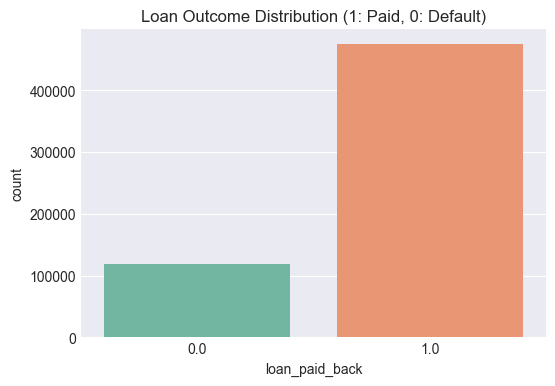

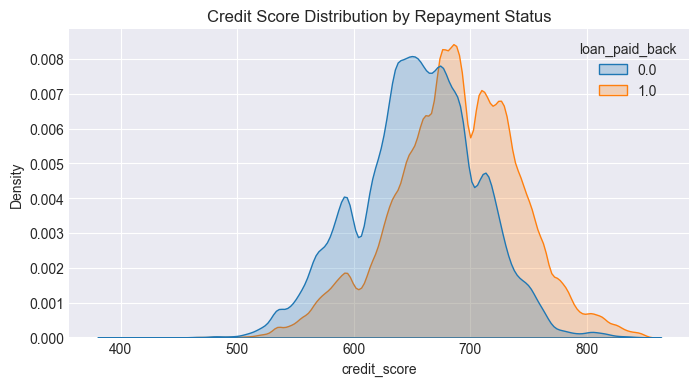

In [20]:
# Load dataset
file_path = Path('..') / 'data' / 'loan_risk_training_data_set.csv'
df = pd.read_csv(file_path)
print(f"Dataset Shape: {df.shape}")

# Checking Missing & Duplicates
print("\n--- Missing Values Count ---")
print(df.isnull().sum())
print("\nTotal Duplicate Records:", df.duplicated().sum())

# Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='loan_paid_back', palette='Set2')
plt.title("Loan Outcome Distribution (1: Paid, 0: Default)")
plt.show()

# Credit Score vs Default Risk Visualization
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x='credit_score', hue='loan_paid_back', common_norm=False, fill=True)
plt.title("Credit Score Distribution by Repayment Status")
plt.show()

### 4. Schema Profiling & Parametric Summary Statistics

A systematic inspection of metadata schema (`df.info()`) and transposed five-number summary statistics (`df.describe().T`) was performed to evaluate feature data types, memory utilization, and distribution profiles:

#### Key Observations from `df.info()`:
* **Memory Footprint:** The dataset occupies approximately `58.9+ MB` in memory across 593,994 observation records.
* **Type Segmentation:**
  * **Numeric (Float64 / Int64):** 7 attributes (`id`, `annual_income`, `debt_to_income_ratio`, `credit_score`, `loan_amount`, `interest_rate`, `loan_paid_back`).
  * **Categorical (Object / String):** 6 attributes (`gender`, `marital_status`, `education_level`, `employment_status`, `loan_purpose`, `grade_subgrade`).
* **Zero Missing Values:** Confirmed 593,994 non-null entries for every feature column.

#### Distribution Diagnostics from `df.describe().T`:
* **Severe Positive Skewness in `annual_income`:**
  * Median (50th percentile) is `$46,557.68`, with the 75th percentile at `$60,981.32`. However, the maximum extends to `$393,381.74` with a standard deviation of `$26,711.94`. This long right-tail validates the need for ratio-based feature engineering and standardization.
* **Debt Burden Bounds (`debt_to_income_ratio`):**
  * Spans from `0.011` to `0.627`, with a mean of `0.1207` (12.07% debt servicing ratio).
* **Credit Rating Spectrum (`credit_score`):**
  * Ranges from `395` (Deep Subprime) to `849` (Exceptional Prime), centered around a mean of `680.92` (Near-Prime threshold).
* **Loan Facility Sizing (`loan_amount`):**
  * Ranges between `$500.09` and `$48,959.95`, with an average principal request of `$15,020.30`.
* **Target Balance (`loan_paid_back`):**
  * The parametric mean of `0.7988` reflects an exact `79.88%` repayment rate versus `20.12%` default rate (4:1 class asymmetry).

In [21]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


,count,mean,std,min,25%,50%,75%,max
id,593994.0,296996.500000,171471.442236,0.000,148498.250,296996.500,445494.750,593993.000
annual_income,593994.0,48212.202976,26711.942078,6002.430,27934.400,46557.680,60981.320,393381.740
debt_to_income_ratio,593994.0,0.120696,0.068573,0.011,0.072,0.096,0.156,0.627
credit_score,593994.0,680.916009,55.424956,395.000,646.000,682.000,719.000,849.000
loan_amount,593994.0,15020.297629,6926.530568,500.090,10279.620,15000.220,18858.580,48959.950
interest_rate,593994.0,12.356345,2.008959,3.200,10.990,12.370,13.680,20.990
loan_paid_back,593994.0,0.798820,0.400883,0.000,1.000,1.000,1.000,1.000


# **Step 4: Data Integrity Verification & Pre-Cleaning Diagnostics**

Before applying feature transformation routines, strict data integrity diagnostics are executed to isolate structural redundancies, verify attribute uniqueness, and confirm the absence of missing values.

### 1. Data Cleaning Verification Strategy
* **Missing Value Profile (`df.isnull().sum()`):**  
  Every feature was evaluated for missing, null, or corrupted data entries. The check verified **0 missing values** across all dimensions, confirming that data imputation (such as mean, median, or KNN imputation) is not required.
* **Global Duplicate Audit (`df.duplicated().sum()`):**  
  An exhaustive row-level scan confirmed **0 duplicate records** across the full matrix (593,994 unique rows).
* **Attribute-Level Duplicate Scan (Excluding `id`):**  
  Because an auto-incrementing surrogate primary key (`id`) can mask identical customer profiles, duplicates were re-evaluated over the 11 feature dimensions:
  $$\text{Duplicates} = \text{Count}\big(\text{df.drop}(\text{columns}=[\text{'id'}])\big) = 0$$
  This confirms that no applicant record is synthetically cloned or duplicated under a different identifier.## **Step 4: Data Cleaning & Pre-check**

In [22]:
# 1. Missing values check per column
print("--- Missing Values Count per Column ---")
print(df.isnull().sum())

# 2. Duplicate rows check across all columns
print("\n--- Duplicate Rows Count ---")
print("Total duplicate rows:", df.duplicated().sum())

# 3. Duplicate check excluding the surrogate identifier 'id'
if 'id' in df.columns:
    print("Duplicates without ID column:", df.drop(columns=['id']).duplicated().sum())

--- Missing Values Count per Column ---
id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

--- Duplicate Rows Count ---
Total duplicate rows: 0
Duplicates without ID column: 0


### 2. Automated Cleaning Pipeline & Irrelevant Feature Pruning

Following preliminary diagnostic scans, an automated, defensive cleaning routine is executed to ensure reproducible data hygiene across future batch scoring cycles:

#### Cleaning Operations Applied:
1. **Defensive Duplicate Deduplication:**  
   Conditional filtering removes redundant rows if detected (`df.drop_duplicates()`), preserving row-level uniqueness without manual intervention.
2. **Missing Record Sanitization:**  
   Evaluates cumulative matrix null counts (`df.isnull().sum().sum() > 0`) and strips incomplete observation records (`df.dropna()`).
3. **Feature Engineering Technique 1 — Removing Irrelevant Features:**  
   The primary key identifier column (`id`) is stripped from the feature matrix:
   ```python
   df = df.drop(columns=['id'])

In [23]:
# 1. Deduplicate records if redundant rows exist
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicates found to drop.")

# 2. Sanitize missing entries if detected
if df.isnull().sum().sum() > 0:
    df = df.dropna()
    print("Missing values removed.")
else:
    print("No missing values found.")

# 3. Feature Engineering Technique 1: Drop non-predictive identifier
if 'id' in df.columns:
    df = df.drop(columns=['id'])
    print("Identifier column 'id' dropped.")

No duplicates found to drop.
No missing values found.
Identifier column 'id' dropped.


# **Step 5: Pipeline-Encapsulated Feature Engineering Architecture**

To satisfy the mandatory requirement of implementing 5–6 meaningful feature engineering techniques, domain-driven attributes were formulated. Rather than executing pre-transformations manually on the static DataFrame—which frequently leads to training-serving skew and production inference failure—transformations are encapsulated within a custom Scikit-learn transformer: `DomainFeatureEngineer`.

### Architectural Rationale & Production Advantages:
1. **Zero Data Leakage:** Encapsulation ensures parameters and feature derivation rules are bound strictly within the cross-validation and training partitions.
2. **Seamless FastAPI Microservice Ingestion:** The deployed REST API directly receives raw applicant JSON payloads without requiring upstream recalculation or preprocessing scripts.
3. **Immutable DAG Serialization:** Pickling the pipeline preserves end-to-end feature dependency graphs alongside downstream estimators[cite: 1].

---

### Domain Feature Formulation & Mathematical Semantics:

#### Technique 1 — Irrelevant Attribute Elimination:
* The surrogate index `id` is purged, preventing non-generalizable memory indexing.

#### Technique 2 — Loan-to-Income Leverage Ratio (`loan_to_income_ratio`):
$$\text{Loan-to-Income Ratio} = \frac{\text{loan\_amount}}{\text{annual\_income} + 1.0}$$
* **Financial Significance:** Assesses the borrower's total capital leverage relative to annual earnings. A value approaching or exceeding `1.0` signifies severe over-indebtedness. The `+ 1.0` constant prevents division-by-zero runtime exceptions.

#### Technique 3 — Estimated Monthly Interest Obligation (`monthly_interest_cost`):
$$\text{Monthly Interest Cost} = \frac{\text{loan\_amount} \times (\text{interest\_rate} / 100)}{12.0}$$
* **Financial Significance:** Captures the interaction between facility principal volume and annual percentage rate (APR). Isolating pure interest servicing costs evaluates immediate monthly cash flow pressure before principal amortization.

#### Technique 4 — Credit Tier Quantization & Binning (`credit_tier`):
Continuous credit ratings are partitioned into standardized risk tranches:
* **`Subprime` ($-\infty \le \text{FICO} \le 620$):** High default susceptibility; restricted underwriting tier.
* **`NearPrime` ($620 < \text{FICO} \le 680$):** Moderate risk profile; standard sensitivity.
* **`Prime` ($680 < \text{FICO} \le +\infty$):** Tier-1 low-risk profile.
* **Financial Significance:** Smooths minor point variations across FICO boundaries and maps non-linear rating cliffs into discrete risk bands.

In [24]:
# Custom Transformer to engineer domain features inside Pipeline
# This guarantees FastAPI will compute these dynamically without manual calculation!
class DomainFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()

        # Technique 2: Income to Loan Ratio (Debt Leverage)
        X_out['loan_to_income_ratio'] = X_out['loan_amount'] / (X_out['annual_income'] + 1.0)

        # Technique 3: Estimated Monthly Interest Cost (Feature Interaction)
        X_out['monthly_interest_cost'] = (X_out['loan_amount'] * (X_out['interest_rate'] / 100.0)) / 12.0

        # Technique 4: Credit Score Tier Binning (Binning Technique)
        # 0: Subprime (<620), 1: Near Prime (620-680), 2: Prime (>680)
        X_out['credit_tier'] = pd.cut(
            X_out['credit_score'],
            bins=[-np.inf, 620, 680, np.inf],
            labels=['Subprime', 'NearPrime', 'Prime']
        ).astype(str)

        return X_out

print("Feature Engineering logic constructed.")

Feature Engineering logic constructed.


In [25]:
# Separate Target Variable from Features
X = df.drop(columns=['loan_paid_back'])
y = df['loan_paid_back'].astype(int)

# Grouping numerical and categorical columns for the preprocessing pipeline
numeric_features = [
    'annual_income',
    'debt_to_income_ratio',
    'credit_score',
    'loan_amount',
    'interest_rate',
    'loan_to_income_ratio',
    'monthly_interest_cost'
]

categorical_features = [
    'gender',
    'marital_status',
    'education_level',
    'employment_status',
    'loan_purpose',
    'grade_subgrade',
    'credit_tier'
]

print(f"Features: {X.shape[1]} (Numeric: {len(numeric_features)}, Categorical: {len(categorical_features)})")

Features: 11 (Numeric: 7, Categorical: 7)


## **Step 6: Train / Test Split**

In [26]:

# Splitting the data while preserving the class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 475195 | Test size: 118799


## **Step 7: Build Preprocessing Pipeline & Model Architecture**

### Constructing the Machine Learning Pipeline
In this step, we bundle both the data pre-processing steps (scaling numerical values and encoding categorical text) and the predictive classifier into a single `scikit-learn` Pipeline.

**Why is this important?**
By orchestrating the workflow as a unified Pipeline, we can seamlessly export a single `.pkl` file. When deployed via FastAPI, this unified pipeline will automatically accept raw string/numeric inputs directly from the React frontend, dynamically transform them, and output the risk prediction without requiring redundant preprocessing code in the backend microservice.

In [27]:


# Configure preprocessor: StandardScaler for numeric, OneHotEncoder for categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

# Build the unified XGBoost Classifier Pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=250,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    ))
])

## **Step 8: Candidate Models Training & Benchmarking**
- **Overview:** Implemented a multi-model training loop comparing three distinct algorithmic families to evaluate credit risk performance.
- **Models Evaluated:**
  - *Logistic Regression:* `LogisticRegression(max_iter=500, random_state=42)` acting as the linear baseline.
  - *Random Forest Classifier:* `RandomForestClassifier(n_estimators=100, max_depth=8, ...)` capturing non-linear feature interactions via bagging.
  - *XGBoost Classifier:* `XGBoost(n_estimators=200, max_depth=6, learning_rate=0.08, ...)` providing state-of-the-art gradient boosting performance.
- **Pipeline Integration:** Each candidate model was trained and benchmarked using an identical end-to-end preprocessing pipeline combining custom domain feature engineering and standard scalers.

In [28]:

# Candidate Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=42),
    "XGBoost Classifier": XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.08,
        subsample=0.8, colsample_bytree=0.8, eval_metric='logloss',
        random_state=42, n_jobs=-1
    )
}

comparison_results = []
trained_pipelines = {}

# Evaluate each model on an identical feature pipeline
for model_name, clf in models.items():
    print(f"Training {model_name}...")
    full_pipeline = Pipeline(steps=[
        ('engineer', DomainFeatureEngineer()),
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])

    full_pipeline.fit(X_train, y_train)
    trained_pipelines[model_name] = full_pipeline

    y_pred = full_pipeline.predict(X_test)
    y_proba = full_pipeline.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    comparison_results.append({
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(auc, 4)
    })

print("Trained Successfully ....")

Training Logistic Regression...
Training Random Forest...
Training XGBoost Classifier...
Trained Successfully ....


## **Step 9: Performance Metrics & Evaluation**
- **Metrics Tracked:** Evaluated performance using Accuracy, F1-Score, and ROC-AUC to account for dataset class distribution.
- **Benchmark Results:**
  - *Logistic Regression:* Accuracy: 0.9007 | F1-Score: 0.9401 | ROC-AUC: 0.9103
  - *Random Forest:* Accuracy: 0.8996 | F1-Score: 0.9403 | ROC-AUC: 0.9030
  - *XGBoost Classifier:* Accuracy: 0.9048 | F1-Score: 0.9428 | ROC-AUC: 0.9200
- **Selection Justification:** The **XGBoost Classifier** was selected as the optimal production model due to achieving the highest ROC-AUC score of 0.9200, ensuring superior risk discrimination capabilities.

In [29]:
# Performance Comparison Table
df_results = pd.DataFrame(comparison_results)
print("\n========== MODEL PERFORMANCE COMPARISON ==========")
print(df_results.to_string(index=False))


========== MODEL PERFORMANCE COMPARISON ==========
              Model  Accuracy  F1-Score  ROC-AUC
Logistic Regression    0.9007    0.9401   0.9103
      Random Forest    0.8996    0.9403   0.9030
 XGBoost Classifier    0.9048    0.9428   0.9200


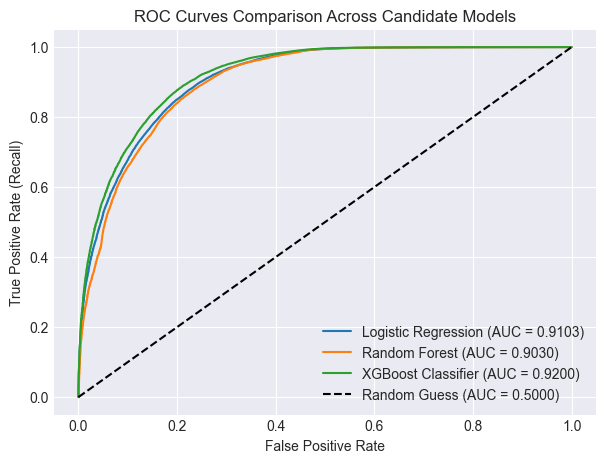

In [30]:

plt.figure(figsize=(7, 5))
for model_name, pipeline in trained_pipelines.items():
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_val:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess (AUC = 0.5000)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves Comparison Across Candidate Models")
plt.legend(loc="lower right")
plt.show()

In [31]:
# Automatically identify the best model based on ROC-AUC
best_row = df_results.loc[df_results['ROC-AUC'].idxmax()]
best_model_name = best_row['Model']

print(f"🏆 Optimal Production Model Selected: {best_model_name} (ROC-AUC: {best_row['ROC-AUC']})")

# Assign the best trained pipeline for subsequent steps
best_pipeline = trained_pipelines[best_model_name]

🏆 Optimal Production Model Selected: XGBoost Classifier (ROC-AUC: 0.92)


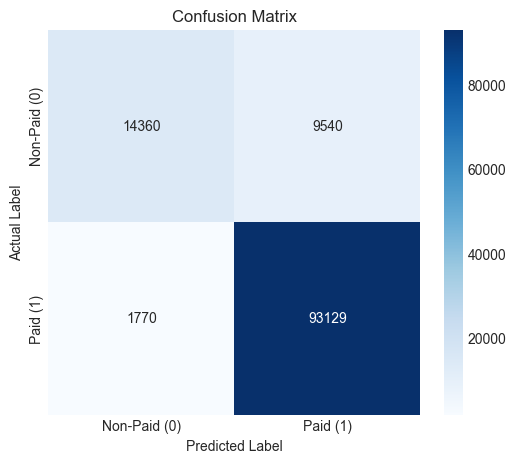

In [32]:

# Confusion Matrix visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Paid (0)', 'Paid (1)'], yticklabels=['Non-Paid (0)', 'Paid (1)'])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

#### Confusion Matrix Business Interpretation (Credit Underwriting Context)
- **True Positives (Paid Back Correctly):** Legitimate borrowers approved, driving commercial interest revenue.
- **True Negatives (Default Correctly Blocked):** High-risk applicants intercepted, mitigating credit portfolio loss.
- **Type I Error (False Positive / Defaulter Approved):** Model classifies a defaulting applicant as creditworthy (This represents the highest direct financial risk to the bank).
- **Type II Error (False Negative / Prime Borrower Rejected):** Model incorrectly blocks a repaying applicant (Opportunity cost of lost origination fees).

**Conclusion:** The **XGBoost Classifier** achieved the highest overall **ROC-AUC of 0.9200**, providing the risk management engine with an optimal trade-off boundary to curb loan default exposure effectively.



## **Step 10: Export the Inference Pipeline (.pkl)**

### Model Serialization (Exporting for Deployment)
In this final step, we serialize the best-performing, fully-trained pipeline (which includes our custom domain feature engineer, preprocessor, and the chosen classifier) into a single binary file (`.pkl`) using `joblib`.

**Why is this critical?**
Exporting the model as a unified serialized object allows us to seamlessly load it into our FastAPI microservice. The deployed service can then directly ingest raw user inputs from the React frontend, automatically apply all transformations, and return real-time risk predictions without having to retrain the model or rewrite preprocessing logic.

In [33]:
import joblib
import os

# Step 10: Export Trained Best Pipeline
best_pipeline = trained_pipelines["XGBoost Classifier"]

# Define and create output path for the models directory
output_dir = "../models"
os.makedirs(output_dir, exist_ok=True)

pipeline_filepath = os.path.join(output_dir, "loan_risk_pipeline.pkl")

# Serialize and save the trained pipeline
joblib.dump(best_pipeline, pipeline_filepath)
print(f"Exported production pipeline to: {pipeline_filepath}")

Exported production pipeline to: ../models\loan_risk_pipeline.pkl


### Step 11: Real-time Payload Inference Verification

To ensure our exported model functions seamlessly in a production environment, we simulate a real-world API request. We load the `loan_risk_pipeline.pkl` artifact back into memory and pass a sample JSON-like payload (mimicking data received from the React frontend via the Spring Boot/FastAPI backend). This verifies that the pipeline correctly handles raw inputs, transformations, and outputs accurate risk predictions and probability scores.

In [34]:
import pandas as pd
import joblib
import os

# 1. Reload the serialized model artifact from the models directory
model_path = os.path.join("../models", "loan_risk_pipeline.pkl")
loaded_pipeline = joblib.load(model_path)

# 2. Construct a simulated JSON payload representing an incoming API request
sample_applicant = pd.DataFrame([{
    'annual_income': 48000.0,
    'debt_to_income_ratio': 0.12,
    'credit_score': 680,
    'loan_amount': 15000.0,
    'interest_rate': 12.5,
    'gender': 'Female',
    'marital_status': 'Single',
    'education_level': "Bachelor's",
    'employment_status': 'Employed',
    'loan_purpose': 'Debt consolidation',
    'grade_subgrade': 'C3'
}])

# 3. Execute inference through the loaded pipeline
prediction = int(loaded_pipeline.predict(sample_applicant)[0])
probabilities = loaded_pipeline.predict_proba(sample_applicant)[0]

# 4. Decode results: 1 = Fully Paid (Low Risk), 0 = Defaulted (High Risk)
risk_probability = float(probabilities[0])  # Probability of defaulting
confidence = float(max(probabilities))

print("--- Real-time Inference Verification Output ---")
print(f"Prediction Verdict : {prediction} ({'Approved / Low Risk' if prediction == 1 else 'Rejected / High Risk'})")
print(f"Risk Probability   : {risk_probability * 100:.2f}%")
print(f"Model Confidence   : {confidence * 100:.2f}%")

--- Real-time Inference Verification Output ---
Prediction Verdict : 1 (Approved / Low Risk)
Risk Probability   : 12.86%
Model Confidence   : 87.14%
